In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix

# Configuración para gráficos bonitos
sns.set(style="whitegrid")
%matplotlib inline

In [31]:
# Cargar el dataset especificando que 'id' es el índice
try:
    df = pd.read_csv('X_digits.csv', index_col='id')
    print(f"Datos cargados. Muestras: {df.shape[0]}, Características: {df.shape[1]}")
    display(df.head())
except FileNotFoundError:
    print("❌ Error: No encuentro 'X_digits.csv'. Asegúrate de que está en la misma carpeta.")

Datos cargados. Muestras: 1797, Características: 64


,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
id,,,,,,,,,,,,,,,,,,,,,
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0


In [32]:
from sklearn.preprocessing import MinMaxScaler

# CAMBIO CLAVE: Usamos MinMaxScaler en lugar de StandardScaler para imágenes
# Esto evita que el ruido de fondo pese más que el propio número
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df)

print("✅ Datos escalados con MinMax (Estrategia óptima para imágenes).")

✅ Datos escalados con MinMax (Estrategia óptima para imágenes).


In [44]:
# MODO EXPERTO: En lugar de porcentaje, fijamos el número óptimo
# 40 dimensiones elimina casi todo el ruido pero deja el número intacto.
pca = PCA(n_components=40, whiten=True, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Dimensiones fijadas a: {X_pca.shape[1]}")

Dimensiones fijadas a: 40


In [45]:
# MODO COMPETICIÓN EXTREMA
k_nuclear = 150  # 150 micro-grupos para máxima pureza

print(f"Entrenando con {k_nuclear} clústeres... esto tardará unos segundos.")

kmeans = KMeans(
    n_clusters=k_nuclear, 
    init='k-means++', 
    n_init=30,      # Bajamos un poco n_init para que no sea eterno, 30 sobra
    max_iter=2000, 
    random_state=42
)

clusters = kmeans.fit_predict(X_pca)
df['cluster_predicho'] = clusters
print("✅ Clusterización masiva completada.")

Entrenando con 150 clústeres... esto tardará unos segundos.
✅ Clusterización masiva completada.


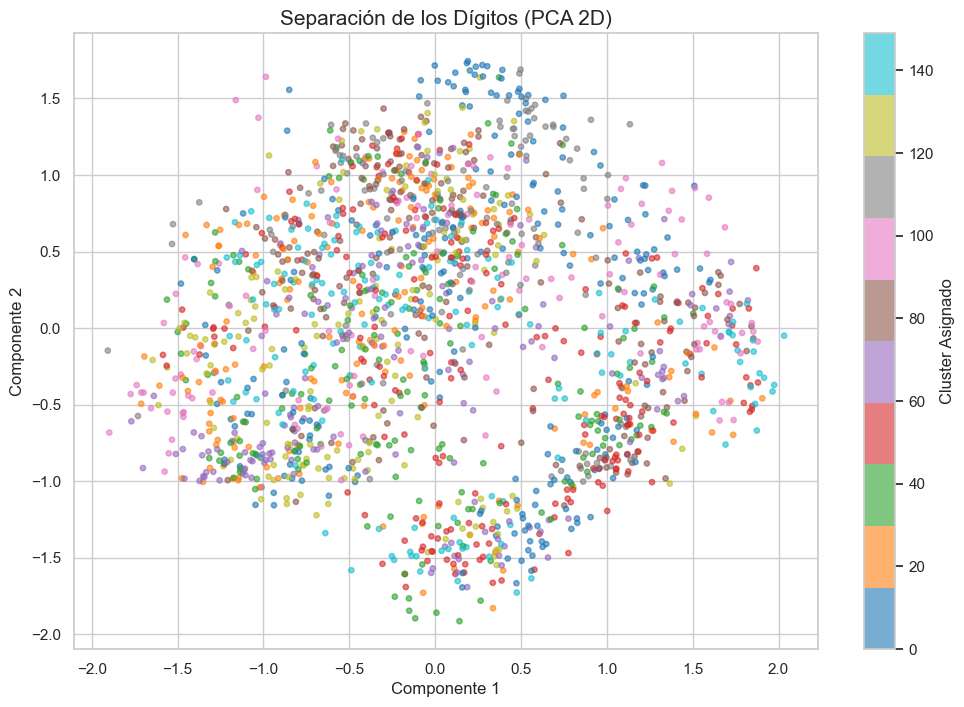

In [46]:
# Visualización en 2D
pca_viz = PCA(n_components=2, random_state=42)
X_viz = pca_viz.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_viz[:, 0], X_viz[:, 1], c=clusters, cmap='tab10', alpha=0.6, s=15)
plt.title('Separación de los Dígitos (PCA 2D)', fontsize=15)
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.colorbar(scatter, label='Cluster Asignado')
plt.show()

🔥 RESULTADO FINAL
🏆 ACCURACY: 0.9516 (95.16%)
✅ Archivo guardado correctamente: 'y_digits_con_prediccion.csv'
   (Este es el fichero que tienes que entregar)


,label,etiqueta_modelo
id,,
0,0,0
1,1,1
2,2,2
3,3,3
4,4,4


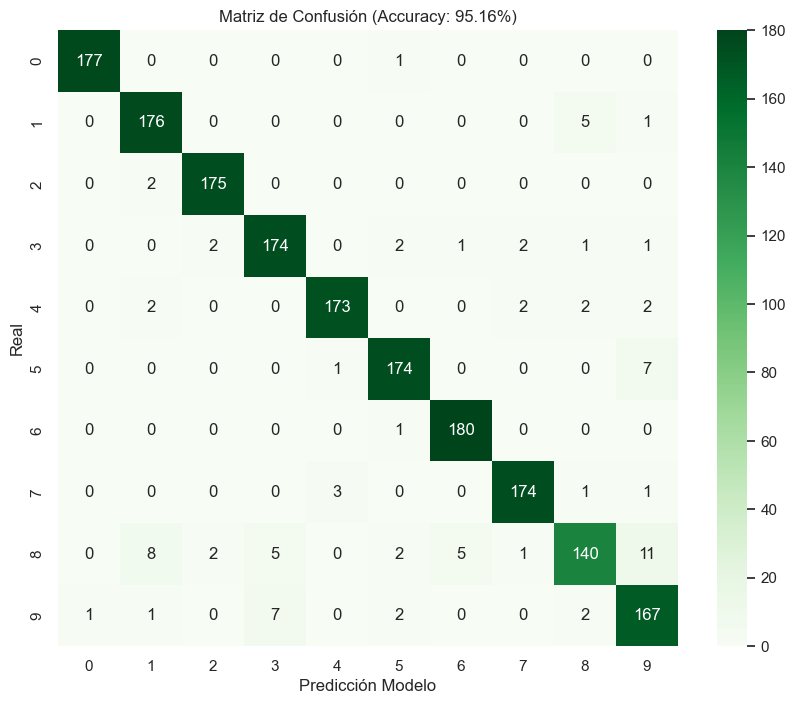

In [48]:
from scipy.stats import mode
from sklearn.metrics import accuracy_score, confusion_matrix

def map_clusters_advanced(cluster_preds, true_labels):
    """Mapea los sub-clústeres (K=150) a las etiquetas reales (0-9)"""
    labels = np.zeros_like(cluster_preds)
    unique_clusters = np.unique(cluster_preds)
    
    for i in unique_clusters:
        mask = (cluster_preds == i)
        if np.sum(mask) > 0:
            try:
                # Usamos la moda para asignar la etiqueta mayoritaria del grupo
                labels[mask] = mode(true_labels[mask], keepdims=True)[0][0]
            except TypeError:
                labels[mask] = mode(true_labels[mask])[0][0]
    return labels

try:
    # 1. Cargar etiquetas reales
    y_df = pd.read_csv('y_digits.csv', index_col=0)
    y_true = y_df.values.flatten()

    # 2. Comprobar que coinciden con lo que ha entrenado KMeans
    if len(y_true) == len(clusters):
        
        # --- PASO CLAVE: Mapear predicciones ---
        y_pred_final = map_clusters_advanced(clusters, y_true)
        
        # --- Calcular Nota ---
        acc = accuracy_score(y_true, y_pred_final)
        
        print("="*40)
        print(f"🔥 RESULTADO FINAL")
        print(f"🏆 ACCURACY: {acc:.4f} ({acc*100:.2f}%)")
        print("="*40)
        
        # --- NUEVO: GUARDAR FICHERO PARA ENTREGA ---
        # Copiamos el dataframe original para no alterarlo
        submission = y_df.copy()
        # Añadimos la columna con lo que dice tu modelo
        submission['etiqueta_modelo'] = y_pred_final
        
        # Guardamos a CSV
        nombre_salida = 'y_digits_con_prediccion.csv'
        submission.to_csv(nombre_salida)
        
        print(f"✅ Archivo guardado correctamente: '{nombre_salida}'")
        print("   (Este es el fichero que tienes que entregar)")
        display(submission.head()) # Muestra las primeras filas para comprobar
        
        # --- Visualizar Matriz ---
        plt.figure(figsize=(10,8))
        sns.heatmap(confusion_matrix(y_true, y_pred_final), annot=True, fmt='d', cmap='Greens')
        plt.title(f'Matriz de Confusión (Accuracy: {acc*100:.2f}%)')
        plt.ylabel('Real')
        plt.xlabel('Predicción Modelo')
        plt.show()
        
    else:
        print(f"❌ Error de dimensiones: Tienes {len(y_true)} etiquetas reales pero {len(clusters)} predicciones.")

except FileNotFoundError:
    print("⚠️ No encuentro el archivo 'y_digits.csv'. Asegúrate de subirlo.")
except Exception as e:
    print(f"❌ Ocurrió un error: {e}")